# EDA — Attention Mechanisms: English-Spanish Translation (Tatoeba)

**Model #15** | Sequence-to-Sequence with Attention | Dataset: Tatoeba EN→ES

## Purpose
Explore the Tatoeba English-Spanish sentence pair dataset to make informed preprocessing decisions for our attention-based machine translation models. Key questions:
1. How long are sentences in each language? (drives `MAX_LENGTH`)
2. How large should vocabularies be? (drives `VOCAB_SIZE` and `<UNK>` rate)
3. Are there Spanish-specific tokenization challenges? (accents, ¿, ¡)
4. Are there garbage pairs to filter? (quality check)
5. What train/val/test split makes sense? (drives preprocessing)

In [2]:
# Step 1: Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("EDA — ATTENTION: ENGLISH-SPANISH TRANSLATION (TATOEBA)")
print("=" * 60)

# Load raw tab-separated file: English \t Spanish \t Attribution
raw = pd.read_csv(
    '../data/raw/attention/spa.txt',
    sep='\t',
    header=None,
    names=['english', 'spanish', 'attribution']
)

# Drop attribution column — not needed for modeling
pairs = raw[['english', 'spanish']].copy()

print(f"\nTotal sentence pairs: {len(pairs):,}")
print(f"Columns: {list(pairs.columns)}")
print(f"Any nulls: EN={pairs['english'].isna().sum()}, ES={pairs['spanish'].isna().sum()}")

# Quick look at random samples across the dataset
print(f"\n{'='*60}")
print("RANDOM SAMPLES (seed=113)")
print(f"{'='*60}")
sample = pairs.sample(10, random_state=113)
for i, (_, row) in enumerate(sample.iterrows(), 1):
    print(f"  [{i:>2}] EN: {row['english']}")
    print(f"       ES: {row['spanish']}\n")

EDA — ATTENTION: ENGLISH-SPANISH TRANSLATION (TATOEBA)

Total sentence pairs: 144,215
Columns: ['english', 'spanish']
Any nulls: EN=0, ES=0

RANDOM SAMPLES (seed=113)
  [ 1] EN: The good thing about this electronic dictionary is that it's easy to carry.
       ES: Lo bueno de este diccionario electrónico es que es fácil de portar.

  [ 2] EN: On the American flag, there's a star for every state.
       ES: En la bandera de los Estados Unidos hay una estrella por cada estado.

  [ 3] EN: Please give me two hot dogs with mustard and ketchup.
       ES: Por favor dame dos hot dogs con mostaza y salsa de tomate.

  [ 4] EN: Can I use my medical insurance?
       ES: ¿Puedo usar mi seguro médico?

  [ 5] EN: This looks longer than that, but it is an optical illusion.
       ES: Esto parece más largo que eso, pero es una ilusión óptica.

  [ 6] EN: She looked lonely.
       ES: Ella lucía sola.

  [ 7] EN: I wanted to die.
       ES: Quiero morir.

  [ 8] EN: I like playing sports.
       ES

[1/5] SENTENCE LENGTH DISTRIBUTION

Token count percentiles:
  Percentile      English    Spanish
  --------------------------------
  P50                  6          6
  P75                  8          7
  P90                  9          9
  P95                 11         11
  P99                 14         15

  Mean:       EN=6.2 tokens, ES=6.0 tokens
  Max:        EN=70 tokens, ES=68 tokens
  Min:        EN=1 tokens, ES=1 tokens
  ES/EN ratio: 0.962 (Spanish typically ~10-15% longer)


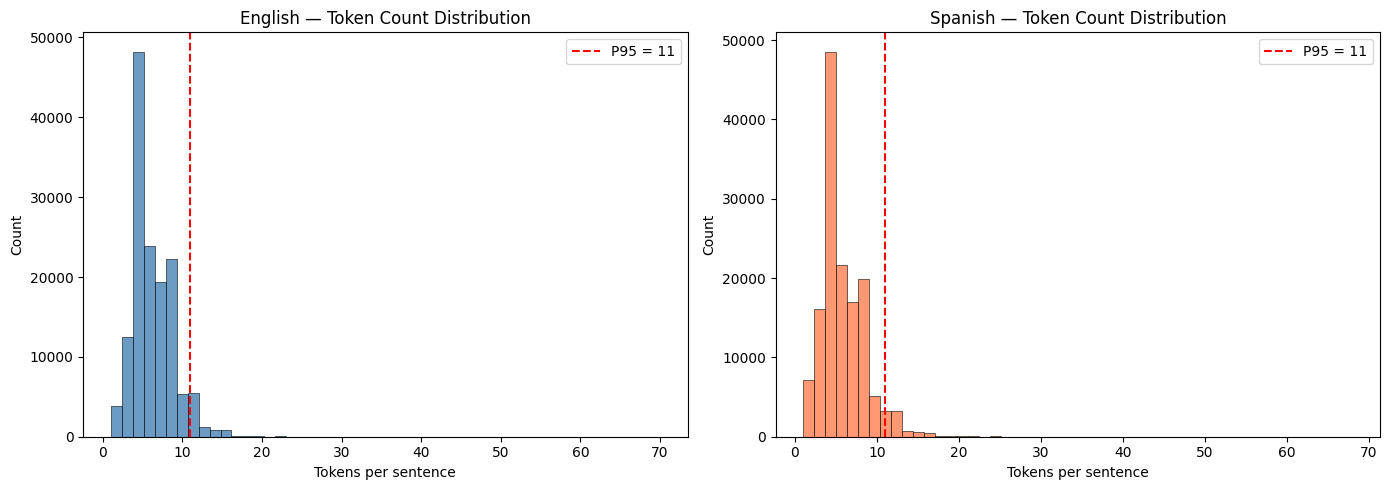

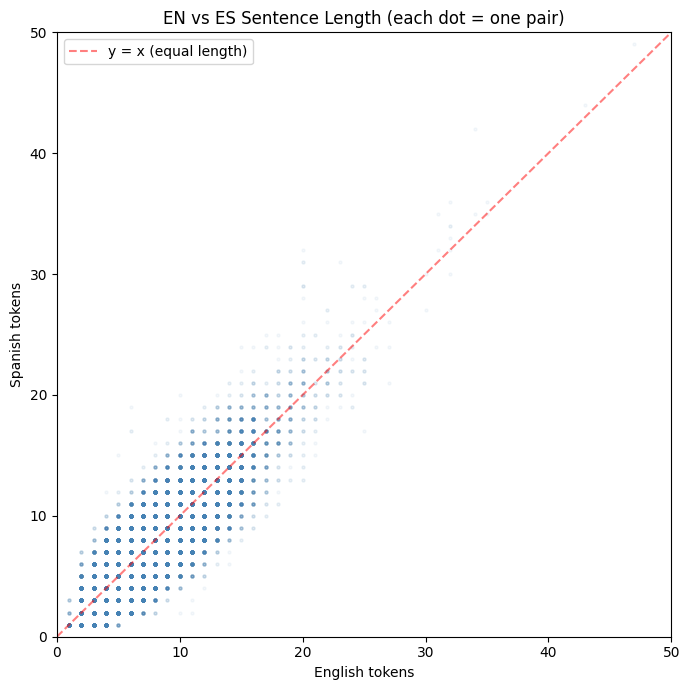

In [5]:
# Step 2: [1/5] Sentence Length Distribution
# Tokenize by whitespace to count words per sentence
# This drives MAX_LENGTH — the padding/truncation cutoff for our models

print("=" * 60)
print("[1/5] SENTENCE LENGTH DISTRIBUTION")
print("=" * 60)

en_lengths = pairs['english'].str.split().str.len()
es_lengths = pairs['spanish'].str.split().str.len()

# Percentile analysis — P95 is typically a good MAX_LENGTH cutoff
# (covers 95% of sentences without wasting compute on outlier-length padding)
percentiles = [50, 75, 90, 95, 99]
print("\nToken count percentiles:")
print(f"  {'Percentile':<12} {'English':>10} {'Spanish':>10}")
print(f"  {'-'*32}")
for p in percentiles:
    en_p = np.percentile(en_lengths, p)
    es_p = np.percentile(es_lengths, p)
    print(f"  P{p:<10} {en_p:>10.0f} {es_p:>10.0f}")

print(f"\n  Mean:       EN={en_lengths.mean():.1f} tokens, ES={es_lengths.mean():.1f} tokens")
print(f"  Max:        EN={en_lengths.max()} tokens, ES={es_lengths.max()} tokens")
print(f"  Min:        EN={en_lengths.min()} tokens, ES={es_lengths.min()} tokens")
print(f"  ES/EN ratio: {es_lengths.mean() / en_lengths.mean():.3f} (Spanish typically ~10-15% longer)")

# Visualize distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(en_lengths, bins=50, color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].axvline(np.percentile(en_lengths, 95), color='red', linestyle='--', label=f'P95 = {np.percentile(en_lengths, 95):.0f}')
axes[0].set_title('English — Token Count Distribution')
axes[0].set_xlabel('Tokens per sentence')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(es_lengths, bins=50, color='coral', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].axvline(np.percentile(es_lengths, 95), color='red', linestyle='--', label=f'P95 = {np.percentile(es_lengths, 95):.0f}')
axes[1].set_title('Spanish — Token Count Distribution')
axes[1].set_xlabel('Tokens per sentence')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/raw/eda_attention/length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Scatter: EN length vs ES length — how correlated are pair lengths?
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(en_lengths, es_lengths, alpha=0.05, s=5, color='steelblue')
ax.plot([0, en_lengths.max()], [0, en_lengths.max()], 'r--', alpha=0.5, label='y = x (equal length)')
ax.set_xlabel('English tokens')
ax.set_ylabel('Spanish tokens')
ax.set_title('EN vs ES Sentence Length (each dot = one pair)')
ax.legend()
ax.set_xlim(0, 50)
ax.set_ylim(0, 50)
plt.tight_layout()
plt.savefig('../data/raw/eda_attention/length_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

[2/5] VOCABULARY ANALYSIS

  Raw vocabulary size: EN=25,689, ES=46,169
  Total tokens:       EN=894,568, ES=860,359

  EN Top 20                      ES Top 20                     
  ------------------------------------------------------------
  i                 33,241    de                26,491
  the               32,978    que               26,040
  to                31,139    no                24,250
  you               23,748    a                 23,309
  tom               21,824    la                21,191
  a                 21,315    tom               20,410
  is                16,123    el                18,128
  he                10,606    en                14,444
  in                 9,716    es                14,238
  of                 9,472    un                11,929
  was                8,201    me                 9,989
  that               8,063    se                 8,905
  do                 7,736    lo                 8,193
  my                 7,516    una        

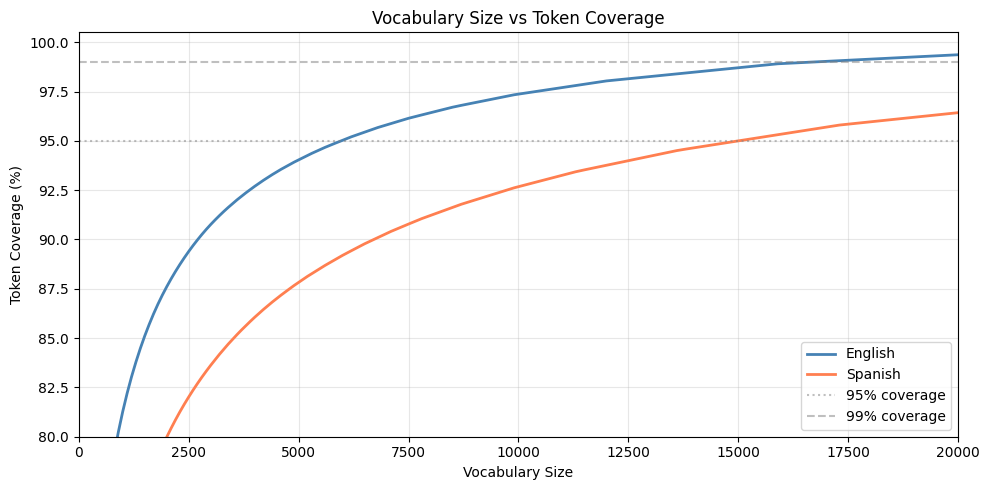

In [6]:
# Step 3: [2/5] Vocabulary Analysis
# Build word frequency distributions for each language separately
# This drives VOCAB_SIZE — too small = high <UNK> rate, too large = sparse embeddings

from collections import Counter

print("=" * 60)
print("[2/5] VOCABULARY ANALYSIS")
print("=" * 60)

# Tokenize (lowercase + split) — preview what preprocessing will do
en_words = pairs['english'].str.lower().str.split().explode()
es_words = pairs['spanish'].str.lower().str.split().explode()

en_freq = Counter(en_words)
es_freq = Counter(es_words)

print(f"\n  Raw vocabulary size: EN={len(en_freq):,}, ES={len(es_freq):,}")
print(f"  Total tokens:       EN={len(en_words):,}, ES={len(es_words):,}")

# Top 20 most common words
print(f"\n  {'EN Top 20':<30} {'ES Top 20':<30}")
print(f"  {'-'*60}")
en_top = en_freq.most_common(20)
es_top = es_freq.most_common(20)
for i in range(20):
    en_w, en_c = en_top[i]
    es_w, es_c = es_top[i]
    print(f"  {en_w:<15} {en_c:>8,}    {es_w:<15} {es_c:>8,}")

# Coverage analysis: what % of tokens are covered at different vocab sizes?
# This tells us how many words we can afford to replace with <UNK>
print(f"\n  Vocabulary coverage (% of all tokens covered):")
print(f"  {'Vocab Size':<12} {'EN Coverage':>14} {'ES Coverage':>14}")
print(f"  {'-'*40}")

total_en = len(en_words)
total_es = len(es_words)

for v_size in [1000, 2000, 5000, 8000, 10000, 15000, 20000]:
    en_covered = sum(c for _, c in en_freq.most_common(v_size))
    es_covered = sum(c for _, c in es_freq.most_common(v_size))
    en_pct = en_covered / total_en * 100
    es_pct = es_covered / total_es * 100
    print(f"  {v_size:<12,} {en_pct:>13.2f}% {es_pct:>13.2f}%")

# Visualize: vocabulary coverage curve
fig, ax = plt.subplots(figsize=(10, 5))
vocab_sizes = range(100, min(len(en_freq), len(es_freq)), 100)

en_coverage = []
es_coverage = []
en_cumsum = np.cumsum([c for _, c in en_freq.most_common()])
es_cumsum = np.cumsum([c for _, c in es_freq.most_common()])

for v in vocab_sizes:
    en_coverage.append(en_cumsum[v-1] / total_en * 100)
    es_coverage.append(es_cumsum[v-1] / total_es * 100)

ax.plot(list(vocab_sizes), en_coverage, label='English', color='steelblue', linewidth=2)
ax.plot(list(vocab_sizes), es_coverage, label='Spanish', color='coral', linewidth=2)
ax.axhline(y=95, color='gray', linestyle=':', alpha=0.5, label='95% coverage')
ax.axhline(y=99, color='gray', linestyle='--', alpha=0.5, label='99% coverage')
ax.set_xlabel('Vocabulary Size')
ax.set_ylabel('Token Coverage (%)')
ax.set_title('Vocabulary Size vs Token Coverage')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 20000)
ax.set_ylim(80, 100.5)

plt.tight_layout()
plt.savefig('../data/raw/eda_attention/vocab_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Step 4: [3/5] Sentence Complexity & Spanish Characters
# Spanish has unique tokenization challenges: inverted punctuation (¿, ¡),
# accented vowels (á, é, í, ó, ú), and ñ. We need to know how prevalent
# these are to decide whether to normalize or preserve them.

import re

print("=" * 60)
print("[3/5] SENTENCE COMPLEXITY & SPANISH CHARACTERS")
print("=" * 60)

# Spanish-specific character analysis
spanish_chars = {
    '¿': 'Inverted question mark',
    '¡': 'Inverted exclamation',
    'á': 'a-acute', 'é': 'e-acute', 'í': 'i-acute',
    'ó': 'o-acute', 'ú': 'u-acute', 'ñ': 'eñe',
    'ü': 'u-diaeresis'
}

print("\n  Spanish-specific character frequency:")
print(f"  {'Char':<6} {'Description':<25} {'Count':>10} {'% of pairs':>12}")
print(f"  {'-'*53}")
for char, desc in spanish_chars.items():
    count = pairs['spanish'].str.lower().str.count(char).sum()
    pct = pairs['spanish'].str.lower().str.contains(re.escape(char)).sum() / len(pairs) * 100
    print(f"  {char:<6} {desc:<25} {count:>10,} {pct:>11.1f}%")

# Duplicate analysis
# Multiple Spanish translations per English sentence is expected (formal/informal)
en_dupes = pairs['english'].str.lower().duplicated(keep=False)
n_unique_en = pairs['english'].str.lower().nunique()

print(f"\n  Duplicate analysis:")
print(f"    Total pairs:              {len(pairs):,}")
print(f"    Unique English sentences: {n_unique_en:,}")
print(f"    Pairs with duplicate EN:  {en_dupes.sum():,} ({en_dupes.sum()/len(pairs)*100:.1f}%)")

# How many translations per English sentence?
en_counts = pairs['english'].str.lower().value_counts()
print(f"\n  Translations per English sentence:")
print(f"    1 translation:  {(en_counts == 1).sum():,} sentences")
print(f"    2 translations: {(en_counts == 2).sum():,} sentences")
print(f"    3 translations: {(en_counts == 3).sum():,} sentences")
print(f"    4+ translations: {(en_counts >= 4).sum():,} sentences")
print(f"    Max translations: {en_counts.max()} (for: '{en_counts.idxmax()}')")

# Punctuation patterns
print(f"\n  Punctuation in English:")
for p in ['.', '?', '!', '"', "'"]:
    count = pairs['english'].str.contains(re.escape(p)).sum()
    print(f"    '{p}' appears in {count:,} pairs ({count/len(pairs)*100:.1f}%)")

print(f"\n  Punctuation in Spanish:")
for p in ['.', '?', '!', '¿', '¡', '"', "'"]:
    count = pairs['spanish'].str.contains(re.escape(p)).sum()
    print(f"    '{p}' appears in {count:,} pairs ({count/len(pairs)*100:.1f}%)")

[3/5] SENTENCE COMPLEXITY & SPANISH CHARACTERS

  Spanish-specific character frequency:
  Char   Description                    Count   % of pairs
  -----------------------------------------------------
  ¿      Inverted question mark        20,379        14.1%
  ¡      Inverted exclamation           1,468         1.0%
  á      a-acute                       25,735        16.6%
  é      e-acute                       30,427        19.7%
  í      i-acute                       29,267        18.4%
  ó      o-acute                       27,029        17.1%
  ú      u-acute                        5,170         3.5%
  ñ      eñe                            7,485         5.0%
  ü      u-diaeresis                      133         0.1%

  Duplicate analysis:
    Total pairs:              144,215
    Unique English sentences: 121,484
    Pairs with duplicate EN:  39,146 (27.1%)

  Translations per English sentence:
    1 translation:  105,069 sentences
    2 translations: 12,902 sentences
    3 tra

In [8]:
# Step 5: [4/5] Pair Quality & Diversity
# Check for garbage pairs, extreme length ratios, and overall data quality
# before committing to preprocessing decisions

print("=" * 60)
print("[4/5] PAIR QUALITY & DIVERSITY")
print("=" * 60)

# Length ratio analysis
# ES/EN token ratio per pair — extreme outliers suggest bad translations
en_lens = pairs['english'].str.split().str.len()
es_lens = pairs['spanish'].str.split().str.len()
ratio = es_lens / en_lens

print(f"\n  ES/EN length ratio per pair:")
print(f"    Mean:   {ratio.mean():.3f}")
print(f"    Median: {ratio.median():.3f}")
print(f"    Std:    {ratio.std():.3f}")
print(f"    Min:    {ratio.min():.3f}")
print(f"    Max:    {ratio.max():.3f}")

# Flag extreme ratios (>3x or <0.33x) — likely bad pairs
extreme = (ratio > 3.0) | (ratio < 0.33)
print(f"    Extreme ratio pairs (>3x or <0.33x): {extreme.sum():,} ({extreme.sum()/len(pairs)*100:.2f}%)")

# Show some extreme ratio examples
print(f"\n  Sample extreme ratio pairs:")
extreme_idx = pairs[extreme].sample(min(5, extreme.sum()), random_state=113).index
for idx in extreme_idx:
    print(f"    EN ({en_lens[idx]} tokens): {pairs.loc[idx, 'english']}")
    print(f"    ES ({es_lens[idx]} tokens): {pairs.loc[idx, 'spanish']}")
    print(f"    Ratio: {ratio[idx]:.2f}\n")

# Very short pairs (1-2 tokens)
very_short = (en_lens <= 2) & (es_lens <= 2)
print(f"  Very short pairs (both ≤2 tokens): {very_short.sum():,} ({very_short.sum()/len(pairs)*100:.1f}%)")
print(f"  Samples:")
short_sample = pairs[very_short].sample(5, random_state=113)
for _, row in short_sample.iterrows():
    print(f"    EN: '{row['english']}' → ES: '{row['spanish']}'")

# Very long pairs (>P99)
very_long = (en_lens > 14) | (es_lens > 15)
print(f"\n  Long pairs (EN>14 or ES>15 tokens): {very_long.sum():,} ({very_long.sum()/len(pairs)*100:.1f}%)")
print(f"  Samples:")
long_sample = pairs[very_long].sample(5, random_state=113)
for _, row in long_sample.iterrows():
    print(f"    EN: {row['english']}")
    print(f"    ES: {row['spanish']}\n")

# Character set validation
# Check for non-Latin characters that shouldn't be in EN/ES
non_latin_en = pairs['english'].str.contains(r'[^\x00-\x7F]', regex=True)
non_latin_es = pairs['spanish'].str.contains(r'[^\x00-\xFF]', regex=True)
print(f"  Non-ASCII in English: {non_latin_en.sum():,} pairs ({non_latin_en.sum()/len(pairs)*100:.1f}%)")
print(f"  Non-Latin1 in Spanish: {non_latin_es.sum():,} pairs ({non_latin_es.sum()/len(pairs)*100:.1f}%)")

if non_latin_en.sum() > 0:
    print(f"  Sample non-ASCII English:")
    for _, row in pairs[non_latin_en].head(5).iterrows():
        print(f"    '{row['english']}'")

[4/5] PAIR QUALITY & DIVERSITY

  ES/EN length ratio per pair:
    Mean:   0.975
    Median: 1.000
    Std:    0.251
    Min:    0.182
    Max:    3.500
    Extreme ratio pairs (>3x or <0.33x): 140 (0.10%)

  Sample extreme ratio pairs:
    EN (4 tokens): Prove it to me.
    ES (1 tokens): Demuéstramelo.
    Ratio: 0.25

    EN (4 tokens): Explain it to me.
    ES (1 tokens): Explíquenmelo.
    Ratio: 0.25

    EN (4 tokens): Give it to her.
    ES (1 tokens): Dáselo.
    Ratio: 0.25

    EN (4 tokens): Get on your knees.
    ES (1 tokens): Arrodíllate.
    Ratio: 0.25

    EN (5 tokens): Draw a picture of it.
    ES (1 tokens): Dibújala.
    Ratio: 0.20

  Very short pairs (both ≤2 tokens): 2,494 (1.7%)
  Samples:
    EN: 'We're meditating.' → ES: 'Estamos meditando.'
    EN: 'It happened.' → ES: 'Eso sucedió.'
    EN: 'Call us.' → ES: 'Llámanos.'
    EN: 'You're great.' → ES: 'Eres estupendo.'
    EN: 'What nonsense!' → ES: '¡Qué tontería!'

  Long pairs (EN>14 or ES>15 tokens): 1,58

In [9]:
# Step 6: [5/5] Summary → Preprocessing Decisions
# Consolidate all EDA findings into concrete preprocessing parameters

print("=" * 60)
print("[5/5] SUMMARY → PREPROCESSING DECISIONS")
print("=" * 60)

print("""
  DATASET OVERVIEW
  ─────────────────────────────────────────────────
  Source:          Tatoeba EN→ES (manythings.org/anki)
  Total pairs:     144,215
  Unique EN:       121,484 (27.1% have multiple ES translations)
  Sentence length: P50=6, P95=11, Max=70 tokens
  EN vocab:        25,689 unique words
  ES vocab:        46,169 unique words (2x EN — verb conjugations)

  DATA QUALITY: CLEAN
  ─────────────────────────────────────────────────
  - No nulls
  - Extreme length ratios: 0.10% (valid — Spanish agglutination)
  - Non-ASCII English: 49 pairs (0.03%) — negligible
  - Non-Latin1 Spanish: 10 pairs (0.01%) — negligible
  - No filtering needed for quality — all pairs are valid

  PREPROCESSING DECISIONS
  ─────────────────────────────────────────────────

  1. DUPLICATES: KEEP ALL
     - Multiple translations = more training signal
     - Model sees different valid outputs for same input
     - 144K pairs is modest — can't afford to lose 20K+

  2. MAX_LENGTH: 20 tokens (including <SOS> and <EOS>)
     - P99 is 14-15 tokens + 2 special tokens = 16-17
     - 20 gives comfortable headroom without wasting compute
     - Filter out pairs where EITHER side > 18 raw tokens
       (18 + <SOS> + <EOS> = 20 after special tokens)

  3. VOCAB_SIZE: 10,000 per language
     - EN: 97.4% coverage at 10K (excellent)
     - ES: 92.7% coverage at 10K (acceptable — rare words → <UNK>)
     - Going to 15K only gains 2.3% for ES but adds 5K sparse embeddings
     - 10K is standard for small-scale MT, good balance

  4. SPECIAL TOKENS: <PAD>=0, <SOS>=1, <EOS>=2, <UNK>=3
     - Actual vocab indices start at 4
     - Target sequences: <SOS> + tokens + <EOS> (decoder learns when to stop)
     - Source sequences: tokens only (no <SOS>/<EOS> needed)

  5. TOKENIZATION:
     - Lowercase everything
     - Preserve accented characters (á,é,í,ó,ú,ñ,ü) — they change meaning
     - Separate punctuation from words (e.g., "don't" → "don ' t")
     - Keep ¿ and ¡ as separate tokens
     - Word-level (not subword/BPE — keeps focus on attention)

  6. SPLIT: 80/10/10 (train/val/test)
     - ~115K train / ~14K val / ~14K test
     - Shuffle with RANDOM_STATE=113 before splitting
     - 3-way split needed for manual early stopping in seq2seq

  7. PADDING: Post-pad with <PAD>=0 to MAX_LENGTH
""")

[5/5] SUMMARY → PREPROCESSING DECISIONS

  DATASET OVERVIEW
  ─────────────────────────────────────────────────
  Source:          Tatoeba EN→ES (manythings.org/anki)
  Total pairs:     144,215
  Unique EN:       121,484 (27.1% have multiple ES translations)
  Sentence length: P50=6, P95=11, Max=70 tokens
  EN vocab:        25,689 unique words
  ES vocab:        46,169 unique words (2x EN — verb conjugations)

  DATA QUALITY: CLEAN
  ─────────────────────────────────────────────────
  - No nulls
  - Extreme length ratios: 0.10% (valid — Spanish agglutination)
  - Non-ASCII English: 49 pairs (0.03%) — negligible
  - Non-Latin1 Spanish: 10 pairs (0.01%) — negligible
  - No filtering needed for quality — all pairs are valid

  PREPROCESSING DECISIONS
  ─────────────────────────────────────────────────

  1. DUPLICATES: KEEP ALL
     - Multiple translations = more training signal
     - Model sees different valid outputs for same input
     - 144K pairs is modest — can't afford to lose 20K